# Gaussian Process Models for Emulation

## Environment

In [11]:
%matplotlib widget

In [12]:
# For fixing type hinting - FIXED in python 3.14 but too restrictive dependency!
from __future__ import annotations  # noqa: F404

# We are going to use JAX for our computation, it will make many things much easier
import jax
from jax import config, vmap
from jax import numpy as jnp
from jax import random as jr
from jax.scipy.linalg import solve_triangular

import equinox as eqx
import optax

from matplotlib import pyplot as plt

from typing import NamedTuple, Tuple, Callable, Union, Optional
from functools import partial


# We will want double precision floats for matrix inversions
config.update("jax_enable_x64", True)

# We will need a "nugget" to support positive definiteness
NUGGET = 1e-9

# Start the random number chain
key = jr.key(0)

## Normal Distributions

The base of most of our computation with GPs will be to manipulate Normal distributions. Let's start by building up a few tools to abstract away much of the repeated effort.

1. Classes for Multivariate Gaussians with either dense, diagonal or isotropic covariances
2. The ability to sample from these
3. How to assess the log likelihood of these distributions

In [13]:
class MultivariateGaussian(eqx.Module):
    """Multivariate Gaussian distribution with a full covariance matrix."""

    mu: jnp.ndarray  # Shape: (N,)
    sigma: jnp.ndarray  # Shape: (N, N)

    @property
    def N(self) -> int:
        """Returns the dimensionality of the distribution."""
        return self.mu.shape[0]

    @property
    def cholesky(self) -> jnp.ndarray:
        """Computes the lower Cholesky decomposition of the covariance matrix."""
        return jnp.linalg.cholesky(self.sigma + NUGGET * jnp.identity(self.N))

    def sample(self, key: jr.PRNGKey, nsamp: int = 1) -> Tuple[jr.PRNGKey, jnp.ndarray]:
        """Generates random samples from the distribution.

        Args:
            key: JAX PRNG key.
            nsamp: Number of samples to generate.

        Returns:
            A tuple of (next_key, samples) where samples has shape (nsamp, N).
        """
        key, subkey = jr.split(key)
        L = self.cholesky

        z = jr.normal(subkey, (self.N, nsamp))
        ys = self.mu[None, :] + (L @ z).T
        return key, ys

    def loglik(self, y: jnp.ndarray) -> jnp.ndarray:
        """Computes the log-likelihood of data point(s) y.

        Args:
            y: Array of shape (N,) or (M, N) containing data points.

        Returns:
            Log-likelihood values.
        """
        L = self.cholesky
        r = jnp.atleast_2d(y) - jnp.atleast_2d(self.mu)
        R = (solve_triangular(L, r.T, lower=True) ** 2).sum(0)

        return -self.N * jnp.log(2 * jnp.pi) / 2 - jnp.log(L.diagonal()).sum() - 0.5 * R


class DiagonalGaussian(eqx.Module):
    """Multivariate Gaussian distribution with a diagonal covariance matrix.

    `sigma` is a 1D array representing variances for each dimension.
    """

    mu: jnp.ndarray  # Shape: (N,)
    sigma: jnp.ndarray  # Shape: (N,) - Variances

    @property
    def N(self) -> int:
        """Returns the dimensionality of the distribution."""
        return self.mu.shape[0]

    def sample(self, key: jr.PRNGKey, nsamp: int = 1) -> Tuple[jr.PRNGKey, jnp.ndarray]:
        """Generates random samples from the distribution."""
        key, subkey = jr.split(key)
        ys = self.mu[None, :] + jr.normal(subkey, (nsamp, self.N)) * jnp.sqrt(
            self.sigma[None, :]
        )
        return key, ys

    def loglik(self, y: jnp.ndarray) -> jnp.ndarray:
        """Computes the log-likelihood of data point(s) y."""
        r = jnp.atleast_2d(y) - jnp.atleast_2d(self.mu)

        return (
            -self.N * jnp.log(2 * jnp.pi) / 2
            - jnp.log(self.sigma).sum() / 2
            - ((r / jnp.sqrt(self.sigma)) ** 2).sum(-1) / 2
        )


class IsotropicGaussian(eqx.Module):
    """Multivariate Gaussian distribution with isotropic variance (identity * scalar)."""

    mu: jnp.ndarray  # Shape: (N,)
    sigma: jnp.ndarray  # Shape: () or (1,) - Scalar variance

    @property
    def N(self) -> int:
        """Returns the dimensionality of the distribution."""
        return self.mu.shape[0]

    def sample(self, key: jr.PRNGKey, nsamp: int = 1) -> Tuple[jr.PRNGKey, jnp.ndarray]:
        """Generates random samples from the distribution."""
        key, subkey = jr.split(key)
        ys = self.mu[None, :] + jr.normal(subkey, (nsamp, self.N)) * jnp.sqrt(
            self.sigma
        )
        return key, ys

    def loglik(self, y: jnp.ndarray) -> jnp.ndarray:
        """Computes the log-likelihood of data point(s) y."""
        r = jnp.atleast_2d(y) - jnp.atleast_2d(self.mu)

        return (
            -self.N * jnp.log(2 * jnp.pi) / 2
            - (self.N * jnp.log(self.sigma)) / 2
            - ((r / jnp.sqrt(self.sigma)) ** 2).sum(-1) / 2
        )

## Covariance Functions


In [14]:
class SE(eqx.Module):
    """Squared Exponential Covariance Function

    Also... Exponentiated Quadratic, RBF, Gaussian...

    Hyperparameters:
        - sf2 (float): signal variance
        - ll (float): length scale

    """

    sf2: float
    ll: float

    def k(self, xp: jnp.ndarray, xq: jnp.ndarray) -> jnp.ndarray:
        """Compute covariance

        Args:
            xp (jnp.ndarray): input x  (D, )
            xq (jnp.ndarray): input x' (D, )

        Returns:
            jnp.ndarray: k(x, x') ( )
        """
        return self.sf2 * jnp.exp(-((xp - xq) ** 2).sum() / 2 / self.ll)


class Mat32(eqx.Module):
    """Matern 3/2 Covariance Function

    General nonlinear covariance function, twice differentiable from \\nu=3/2

    Hyperparameters:
        - sf2 (float): signal variance
        - ll (float): length scale

    """

    sf2: float
    ll: float

    def k(self, xp, xq):
        """Compute covariance

        Args:
            xp (jnp.ndarray): input x  (D, )
            xq (jnp.ndarray): input x' (D, )

        Returns:
            jnp.ndarray: k(x, x') ( )
        """
        r = jnp.sqrt(3) * jnp.sqrt(((xp - xq) ** 2).sum())
        return self.sf2 * (1 + r / self.ll) * jnp.exp(-r / self.ll)


class Periodic(eqx.Module):
    """Periodic Covariance Function

    Models functions that repeat themselves exactly with a given period.

    Hyperparameters:
        - sf2 (float): signal variance
        - ll (float): length scale (controls the smoothness/wobble)
        - pp (float): period (the distance between repetitions)

    """

    sf2: float
    ll: float
    pp: float

    def k(self, xp, xq):
        """Compute covariance

        Args:
            xp (jnp.ndarray): input x  (D, )
            xq (jnp.ndarray): input x' (D, )

        Returns:
            jnp.ndarray: k(x, x') ( )
        """
        r = jnp.pi * jnp.sqrt(((xp - xq) ** 2).sum()) / self.pp
        return self.sf2 * jnp.exp(-2 * jnp.sin(r) ** 2 / self.ll**2)


class Linear(eqx.Module):
    """Linear Basis Covariance Function

    All linear in the parameters models can share a covariance function.

    User can provide basis function (N, D) -> (N, F), default identity function

    Hyperparameters:
        - sf2 (float): signal variance (prior variance of the weights)
        - basis (Callable): feature mapping function phi(x) that maps a
                            (D, ) input to a (F, ) feature vector.
                            Defaults to the identity function.

    """

    sf2: float
    basis: Callable[[jnp.ndarray], jnp.ndarray] = lambda xx: xx

    def k(self, xp, xq):
        """Compute covariance

        Args:
            xp (jnp.ndarray): input x  (D, )
            xq (jnp.ndarray): input x' (D, )

        Returns:
            jnp.ndarray: k(x, x') ( )
        """
        return self.sf2 * jnp.inner(self.basis(xp), self.basis(xq))


class SumKernel(eqx.Module):
    k1: Kernel
    k2: Kernel

    def k(self, xp: jnp.ndarray, xq: jnp.ndarray) -> jnp.ndarray:
        return self.k1.k(xp, xq) + self.k2.k(xp, xq)


class ProductKernel(eqx.Module):
    k1: Kernel
    k2: Kernel

    def k(self, xp: jnp.ndarray, xq: jnp.ndarray) -> jnp.ndarray:
        return self.k1.k(xp, xq) * self.k2.k(xp, xq)


# Maintain a type to hold our covariance kernels for type hinting
Kernel = SE | Mat32 | Periodic | Linear | SumKernel | ProductKernel

In [15]:
def covariance(kernel: Kernel) -> Callable:
    """Create Pairwise Covariance Function from Kernel

    Args:
        kernel (Kernel): class of kernel we want to use

    Returns:
        Callabel : function to produce pairwise K_{ab}
    """
    return vmap(vmap(kernel.k, in_axes=(None, 0)), in_axes=(0, None))


def diagonal_covariance(kernel: Kernel) -> Callable:
    """Diagonal covariance of a Gram matrix

    Will return diagonal of square covariance K_{aa}

    Args:
        kernel (Kernel): class of kernel we want to use

    Returns:
        Callabel : function to produce pairwise K_{ii}
    """
    return vmap(lambda xx: kernel.k(xx, xx))


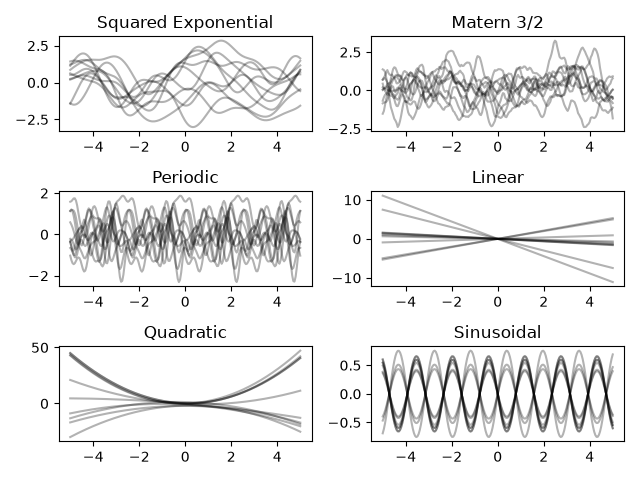

In [16]:
# Sample from some kernels

x = jnp.linspace(-5.0, 5.0, 200)

k_se = SE(1.0, 0.5)
k_mat = Mat32(1.0, 0.5)
k_per = Periodic(1.0, 0.5, 2.5)
k_lin = Linear(1.0)
k_quad = Linear(1.0, lambda xx: xx ** jnp.arange(3))
k_sin = Linear(1.0, lambda xx: jnp.sin(4 * xx))
kerns = [
    ("Squared Exponential", k_se),
    ("Matern 3/2", k_mat),
    ("Periodic", k_per),
    ("Linear", k_lin),
    ("Quadratic", k_quad),
    ("Sinusoidal", k_sin),
]


def sample_kernel(key: jr.PRNGKey, kernel: Kernel, x: jnp.ndarray, nsamp: int = 10):
    gp_prior = MultivariateGaussian(jnp.zeros((x.shape[0])), covariance(kernel)(x, x))
    return gp_prior.sample(key, nsamp=nsamp)


# Plot samples from different covariance functions (zero mean)
fig = plt.figure()
ax = fig.subplots(3, 2)
for i, (nme, kk) in enumerate(kerns):
    plt_idx = (i // 2, i % 2)
    key, ys = sample_kernel(key, kk, x)
    ax[*plt_idx].plot(x, ys.T, "k", alpha=0.3)
    ax[*plt_idx].set_title(nme)

plt.tight_layout()


### Kernel Composition

We can also compose kernels either by addition or by element-wise multiplication. There is some nice discussion in the [Kernel Cookbook](https://www.cs.toronto.edu/~duvenaud/cookbook/) which does a similar thing to this section of the notebook. I would say that some of the discussion there is a little dated now (particularly on the software recommendations) but the core concepts remain solid.

We will use similar examples to those in the cookbook for our kernel compositions.

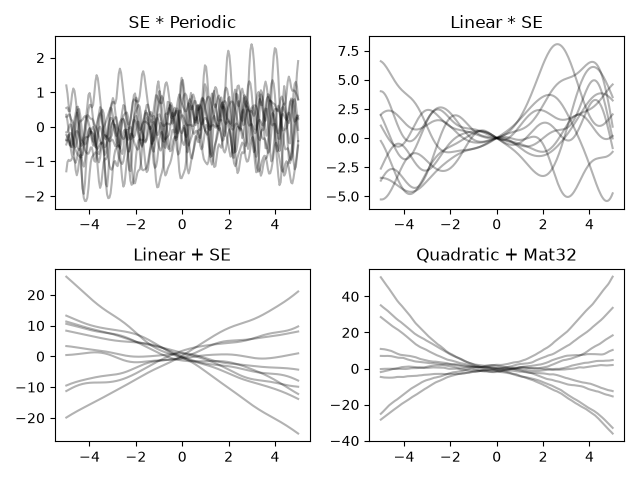

In [17]:
k_per_se = ProductKernel(SE(1.0, 10.0), Periodic(0.5, 1.0, 1.0))
k_lin_se_times = ProductKernel(SE(1.0, 1.0), Linear(1.0))
k_lin_se_add = SumKernel(SE(1.0, 1.0), Linear(4.0))
k_per_mat = SumKernel(k_quad, Mat32(0.5, 0.75))

comb_kerns = [
    ("SE * Periodic", k_per_se),
    ("Linear * SE", k_lin_se_times),
    ("Linear + SE", k_lin_se_add),
    ("Quadratic + Mat32", k_per_mat),
]

# Plot samples from different covariance functions (zero mean)
fig = plt.figure()
ax = fig.subplots(2, 2)
for i, (nme, kk) in enumerate(comb_kerns):
    plt_idx = (i // 2, i % 2)
    key, ys = sample_kernel(key, kk, x)
    ax[*plt_idx].plot(x, ys.T, "k", alpha=0.3)
    ax[*plt_idx].set_title(nme)

plt.tight_layout()

## Mean Functions

In [18]:
class ZeroMean(eqx.Module):
    """Zero Mean Function.

    Returns a static mean of zero for all input locations.
    """

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        """Evaluates the mean function.

        Args:
            x (jnp.ndarray): Input data array of shape (N, D).

        Returns:
            jnp.ndarray: A vector of zeros of shape (N,).
        """
        return jnp.zeros((x.shape[0],))


class LinearMean(eqx.Module):
    """Linear Basis Mean Function.

    Covariance for all models we can write as:
        k(x,x') = \\sigma_f^2 <\\phi(x), \\phi(x')>

    Including linear, polynomial etc.

    Hyperparameters:
        - w (jnp.ndarray): Weight vector of shape (F,).
        - basis (Callable): Feature mapping function phi(x) that maps
                            an (N, D) input to an (N, F) feature matrix.
    """

    w: jnp.ndarray
    basis: Callable[[jnp.ndarray], jnp.ndarray] = lambda xx: xx

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        """Evaluates the mean function.

        Args:
            x (jnp.ndarray): Input data array of shape (N, D).

        Returns:
            jnp.ndarray: Linear mean predictions of shape (N,).
        """
        return jnp.dot(jnp.atleast_1d(self.basis(x)), self.w)


MeanFunction = ZeroMean | LinearMean

## Exact GP Inference

In [19]:
# GP Functions


class ExactGPState(eqx.Module):
    """State of GP

    We can precompute and store the cholesky factor of \\tilde{K} and the
    "woodbury" coefficients \\tilde{K} \\alpha = y computed by backsubstitution

    """

    L: jnp.ndarray  # Lower Cholesky of \tilde{K} = K_{ff} + \sigma_n^2 I
    alpha: jnp.ndarray


class ExactGP(eqx.Module):
    """Exact Gaussian Process Regression Model.

    Work with GP models for

    y = f(x), f(x) ~ GP( m(x), k(x, x') )

    """

    mean: MeanFunction
    kernel: Kernel

    def update_state(self, x: jnp.ndarray, y: jnp.ndarray) -> ExactGPState:
        """Compute GP state from training data.

        Args:
            x (jnp.ndarray): Training inputs of shape (N, D).
            y (jnp.ndarray): Training targets of shape (N, ).

        Returns:
            ExactGPState: State containing important variables.
        """
        N = x.shape[0]
        # Compute the training covariance matrix with a nugget for numerical stability
        ktilde = covariance(self.kernel)(x, x) + NUGGET * jnp.identity(N)
        L = jnp.linalg.cholesky(ktilde)

        # Compute alpha = K^-1 * y via back-substitution: L^T * L * alpha = y - m(x)
        y -= self.mean(x)
        alpha = solve_triangular(
            L, solve_triangular(L, y, lower=True), lower=True, trans=True
        )

        return ExactGPState(L, alpha)

    def predict(
        self, x: jnp.ndarray, xs: jnp.ndarray, state: ExactGPState
    ) -> MultivariateGaussian:
        """Compute full posterior predictive

        Args:
            x (jnp.ndarray): Training inputs of shape (N, D).
            xs (jnp.ndarray): Test inputs of shape (Ns, D).
            state (ExactGPState): GP state from `update_state`.

        Returns:
            MultivariateGaussian: posterior predictive
        """
        cov = covariance(self.kernel)
        ksx = cov(xs, x)
        kss = cov(xs, xs)

        # m = m(xs) + K_sx * K_xx^-1 * y = m(xs) + K_sx * alpha
        m = self.mean(xs) + ksx @ state.alpha

        # v = K_ss - K_sx * K_xx^-1 * K_xs
        R = solve_triangular(state.L, ksx.T, lower=True)
        v = kss - R.T @ R

        return MultivariateGaussian(m, v)

    def predict_marginal(
        self, x: jnp.ndarray, xs: jnp.ndarray, state: ExactGPState
    ) -> DiagonalGaussian:
        """Compute marginal predictive

        Often we don't need the cross covariance of the predictive so
        it is more efficient to only compute the diagonal

        Args:
            x (jnp.ndarray): Training inputs of shape (N, D)
            xs (jnp.ndarray): Test inputs of shape (Ns, D)
            state (ExactGPState): GP state from `update_state`

        Returns:
            DiagonalGaussian: marginal posterior distributions
        """
        ksx = covariance(self.kernel)(xs, x)
        kss = diagonal_covariance(self.kernel)(xs)  # Only pull diagonal elements

        m = self.mean(xs) + ksx @ state.alpha

        R = solve_triangular(state.L, ksx.T, lower=True)
        v = kss - (R**2).sum(0)

        return DiagonalGaussian(m, v)

    def nlml(self, x: jnp.ndarray, y: jnp.ndarray, state: ExactGPState) -> jnp.ndarray:
        """Negative Log Marginal Likelihood

        Args:
            x (jnp.ndarray): Training inputs (N, D).
            y (jnp.ndarray): Training targets (N, ).
            state (ExactGPState): GP state from `update_state`.

        Returns:
            jnp.ndarray: negative log marginal likelihood (scalar)
        """
        N = x.shape[0]
        R = solve_triangular(state.L, y, lower=True)

        # N/2 log(2π) + 0.5 log |Ktilde| + 0.5 *(y' Ktilde^-1 y)
        return (
            N / 2 * jnp.log(2 * jnp.pi)
            + jnp.log(state.L.diagonal()).sum()
            + (R**2).sum() / 2
        )

In [20]:
def plot_gp(
    x: jnp.ndarray,
    y: jnp.ndarray,
    posterior: Union["MultivariateGaussian", "DiagonalGaussian", "IsotropicGaussian"],
    ax: Optional[plt.Axes] = None,
    nsig: Union[float, int] = 3,
) -> None:
    """
    Plots the true data, the GP mean prediction, and a shaded uncertainty region.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    classname = type(posterior).__name__

    if "Multivariate" in classname:
        std = jnp.sqrt(posterior.sigma.diagonal())
    elif "Diagonal" in classname:
        std = jnp.sqrt(posterior.sigma)
    elif "Isotropic" in classname:
        std = jnp.sqrt(posterior.sigma) * jnp.ones_like(posterior.mu)
    else:
        raise TypeError(f"Unsupported posterior distribution type: {classname}")

    x_plot = jnp.atleast_1d(x).squeeze()
    mean_plot = jnp.atleast_1d(posterior.mu).squeeze()
    std_plot = jnp.atleast_1d(std).squeeze()

    lower_bound = mean_plot - nsig * std_plot
    upper_bound = mean_plot + nsig * std_plot

    ax.plot(x, y, color="black", linestyle="--", label="Observed Data")
    ax.plot(x_plot, mean_plot, color="tab:blue", lw=2, label="GP Mean")

    ax.fill_between(
        x_plot,
        lower_bound,
        upper_bound,
        color="tab:blue",
        alpha=0.2,
        label=f"±{nsig} Std. Dev.",
    )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(loc="best")
    ax.grid(True, linestyle="--", alpha=0.5)

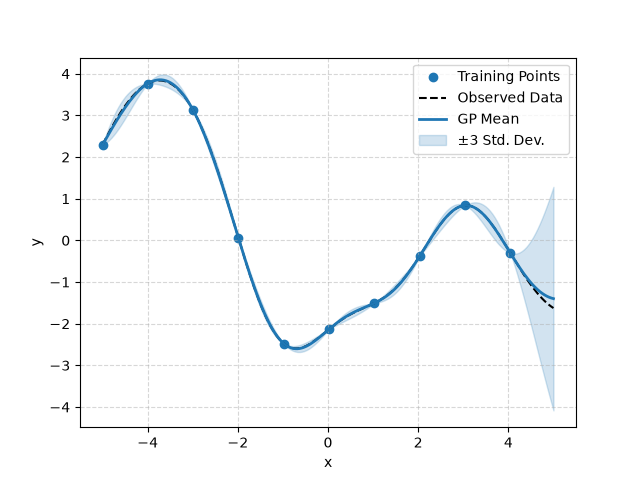

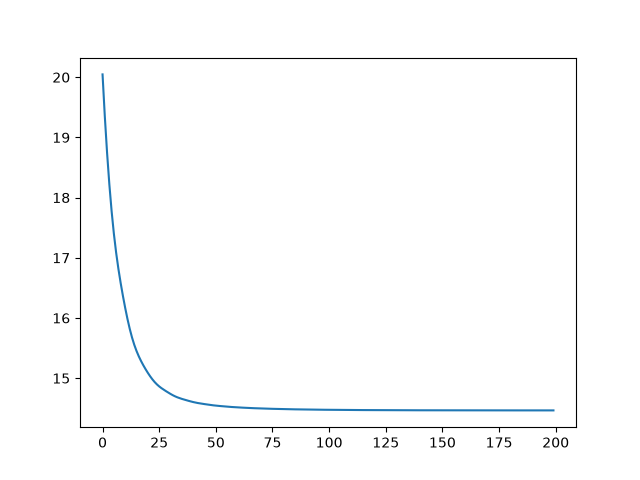

In [52]:
# GP Hyperparameter Optimisation

m = ZeroMean()  # LinearMean(jnp.array(1.0))
k = SE(4.0, 2.0)
gp = ExactGP(m, k)

x = jnp.linspace(-5.0, 5.0, 200)
key, y = sample_kernel(key, k, x, 1)
y = m(x) + y.squeeze()
xtr = x[::20]
ytr = y[::20]


def fit(
    data: Tuple[jnp.ndarray, jnp.ndarray], gp: ExactGP, opt, max_iters: int = 200
) -> Tuple[ExactGP, ExactGPState]:

    trainable, static = eqx.partition(gp, eqx.is_array_like)

    # Apply positive transform on kernel hyperparameters.
    transform_mask = jax.tree_util.tree_map(lambda _: False, trainable)
    transform_mask = eqx.tree_at(
        lambda m: m.kernel,
        transform_mask,
        replace_fn=lambda subtree: jax.tree.map(eqx.is_array_like, subtree),
    )

    def _param_mapping(tree):
        return jax.tree.map(
            lambda x, mask: jnp.log(1 + jnp.exp(x)) if mask else x, tree, transform_mask
        )

    def _inv_param_mapping(tree):
        return jax.tree.map(
            lambda x, mask: jnp.log(jnp.exp(x) - 1) if mask else x, tree, transform_mask
        )

    # Move parameters to training space
    trainable = _inv_param_mapping(trainable)

    def _cost(trainable: ExactGP, static: ExactGP):
        trainable = _param_mapping(trainable)
        model = eqx.combine(trainable, static)
        state = model.update_state(*data)
        cost = model.nlml(*data, state)
        return cost

    _cost_frozen = jax.value_and_grad(jax.jit(partial(lambda tt: _cost(tt, static))))

    def _step(carry, xs):
        train, opt_state = carry
        v, g = _cost_frozen(train)
        updates, opt_state = opt.update(g, opt_state)
        train = optax.apply_updates(train, updates)
        return (train, opt_state), v

    opt_state = opt.init(trainable)
    (trainable, opt_state), cost_log = jax.lax.scan(
        _step, (trainable, opt_state), None, length=max_iters
    )

    return (eqx.combine(trainable, static), cost_log)


fig = plt.figure()
ax = fig.add_subplot()
ax.scatter(xtr, ytr, label="Training Points")

opt = optax.adam(1e-1)
# Make some initial hyperparameters all 1.0 - usually just set as you build the gp
gp0 = jax.tree.map(lambda xx: 1.0 if eqx.is_array_like(xx) else xx, gp)

gp_opt, cost_log = fit((xtr, ytr), gp0, opt)

gp_state = gp_opt.update_state(xtr, ytr)
posterior_predictive = gp_opt.predict_marginal(xtr, x, gp_state)
plot_gp(x, y, posterior_predictive, ax, 3)

jax.block_until_ready(gp_state)


plt.figure()
plt.plot(cost_log)

In [ ]:
class FITCGPState(NamedTuple):
    """Precomputed numerical state for efficient FITC inference.

    Attributes:
        L_z (jnp.ndarray): Lower Cholesky factor of the inducing-to-inducing
                           covariance matrix plus nugget, shape (M, M).
        L_beta (jnp.ndarray): Lower Cholesky factor of the modified capacity matrix
                              (I + V^T D^-1 V), shape (M, M).
        gamma (jnp.ndarray): Data fit vector used for quick mean predictions, shape (M,).
        D_inv (jnp.ndarray): Inverted diagonal residual training variance, shape (N,).
    """

    L_z: jnp.ndarray
    L_beta: jnp.ndarray
    gamma: jnp.ndarray
    D_inv: jnp.ndarray


class FITCGP(NamedTuple):
    """Fully Independent Training Conditional (FITC) Sparse Gaussian Process.

    Approximates exact GP regression by assuming training points are conditionally
    independent given a set of M inducing inputs. Reduces computational complexity
    from O(N^3) to O(N * M^2).
    """

    mean: MeanFunction
    kernel: Kernel

    def update_state(
        self, x: jnp.ndarray, y: jnp.ndarray, z: jnp.ndarray
    ) -> FITCGPState:
        """Precomputes the sparse GP state using training data and inducing inputs.

        Args:
            x (jnp.ndarray): Training inputs of shape (N, D).
            y (jnp.ndarray): Training targets of shape (N, ).
            z (jnp.ndarray): Inducing point inputs of shape (M, D).

        Returns:
            FITCGPState: Precomputed components for O(M^2) predictions and NLML evaluation.
        """
        N = x.shape[0]
        M = z.shape[0]

        cov = covariance(self.kernel)

        # 1. Inducing-inducing covariance math
        K_zz = cov(z, z) + NUGGET * jnp.identity(M)
        L_z = jnp.linalg.cholesky(K_zz)

        # 2. Cross-covariance and diagonal self-covariance
        K_xz = cov(x, z)
        K_xx_diag = diagonal_covariance(self.kernel)(x, x)

        # 3. Compute V = L_z^-1 * K_zx  -> Shape: (M, N)
        V = solve_triangular(L_z, K_xz.T, lower=True)

        # 4. Compute diagonal matrix D = diag(K_xx - Q_xx) + Nugget
        # Q_xx diagonal is the column-wise squared sum of V
        Q_xx_diag = (V**2).sum(axis=0)
        D = K_xx_diag - Q_xx_diag + NUGGET
        D_inv = 1.0 / D

        # 5. Construct the inner capacity matrix: Beta = I + V * D^-1 * V^T
        # Scaled inner product to exploit Woodbury identity matrix inversion
        Beta = jnp.identity(M) + (V * D_inv) @ V.T
        L_beta = jnp.linalg.cholesky(Beta)

        # 6. Compute predictive weight vector gamma = Beta^-1 * V * D^-1 * y
        V_Dinv_y = (V * D_inv) @ y
        gamma = solve_triangular(
            L_beta,
            solve_triangular(L_beta, V_Dinv_y, lower=True),
            lower=True,
            trans=True,
        )

        return FITCGPState(L_z, L_beta, gamma, D_inv)

    def predict(
        self, x: jnp.ndarray, xs: jnp.ndarray, z: jnp.ndarray, state: FITCGPState
    ) -> MultivariateGaussian:
        """Computes the full joint posterior predictive distribution at test locations.

        Args:
            x (jnp.ndarray): Training inputs of shape (N, D).
            xs (jnp.ndarray): Test inputs of shape (Ns, D).
            z (jnp.ndarray): Inducing point inputs of shape (M, D).
            state (FITCGPState): The precomputed sparse GP state.

        Returns:
            MultivariateGaussian: Predictive mean and full joint covariance matrix.
        """
        cov = covariance(self.kernel)
        K_sz = cov(xs, z)
        K_ss = cov(xs, xs)

        # Compute U = L_z^-1 * K_zs  -> Shape: (M, Ns)
        U = solve_triangular(state.L_z, K_sz.T, lower=True)

        # Predictive mean: m = K_sz * K_zz^-1 * V * D^-1 * y = U^T * gamma
        m = U.T @ state.gamma

        # Predictive full covariance via Woodbury projection
        W = solve_triangular(state.L_beta, U, lower=True)
        v = K_ss - U.T @ U + W.T @ W

        return MultivariateGaussian(m, v)

    def predict_marginal(
        self, x: jnp.ndarray, xs: jnp.ndarray, z: jnp.ndarray, state: FITCGPState
    ) -> DiagonalGaussian:
        """Computes the marginal posterior predictive variances at test locations.

        Args:
            x (jnp.ndarray): Training inputs of shape (N, D).
            xs (jnp.ndarray): Test inputs of shape (Ns, D).
            z (jnp.ndarray): Inducing point inputs of shape (M, D).
            state (FITCGPState): The precomputed sparse GP state.

        Returns:
            DiagonalGaussian: Predictive mean and marginal variance vectors.
        """
        K_sz = covariance(self.kernel)(xs, z)
        K_ss_diag = diagonal_covariance(self.kernel)(xs, xs)

        U = solve_triangular(state.L_z, K_sz.T, lower=True)

        m = U.T @ state.gamma

        # Efficient row-wise operations instead of full matrix multiplication
        W = solve_triangular(state.L_beta, U, lower=True)
        v = K_ss_diag - (U**2).sum(axis=0) + (W**2).sum(axis=0)

        return DiagonalGaussian(m, v)

    def nlml(
        self, x: jnp.ndarray, y: jnp.ndarray, z: jnp.ndarray, state: FITCGPState
    ) -> jnp.ndarray:
        """Computes the Negative Log Marginal Likelihood (NLML) for the FITC approximation.

        Args:
            x (jnp.ndarray): Training inputs of shape (N, D).
            y (jnp.ndarray): Training targets of shape (N, ).
            z (jnp.ndarray): Inducing point inputs of shape (M, D).
            state (FITCGPState): The precomputed sparse GP state.

        Returns:
            jnp.ndarray: Scalar objective value for hyperparameter and inducing input tuning.
        """
        N = x.shape[0]

        # 1. Determinant log terms: log|Q_xx + D| = log|D| + log|Beta|
        log_det_D = -jnp.log(state.D_inv).sum()
        log_det_beta = 2.0 * jnp.log(state.L_beta.diagonal()).sum()

        # 2. Data fit term: y^T * (Q_xx + D)^-1 * y
        # Using Woodbury: y^T * D^-1 * y - y^T * D^-1 * V^T * Beta^-1 * V * D^-1 * y
        cov = covariance(self.kernel)
        K_xz = cov(x, z)
        V = solve_triangular(state.L_z, K_xz.T, lower=True)

        y_Dinv_y = (y**2 * state.D_inv).sum()
        V_Dinv_y = (V * state.D_inv) @ y
        R = solve_triangular(state.L_beta, V_Dinv_y, lower=True)
        data_fit = y_Dinv_y - (R**2).sum()

        return (
            N / 2.0 * jnp.log(2.0 * jnp.pi)
            + 0.5 * (log_det_D + log_det_beta)
            + 0.5 * data_fit
        )